In [9]:
import os
os.chdir('../')  

import joblib
import numpy as np
import sys
sys.path.append('src')

from src.preprocess import run_preprocessing_pipeline

X_train, X_test, y_train, y_test = run_preprocessing_pipeline(
    'data/raw/hypothyroid.data'
)
print(" Data ready for modeling")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")


--- SUCCESS: DATA LOADED ---
Total Patients: 3163
Total Features: 30

Raw target values:
target
negative       3012
hypothyroid     151
Name: count, dtype: int64
Binary target — 0 (normal): 3012, 1 (hypothyroid): 151
Columns remaining after drop: 21
Missing values after cleaning: 0

Feature columns (20): ['age', 'sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH', 'T3', 'TT4', 'T4U']
Scaler saved.
Before SMOTE — 0: 2409, 1: 121
After  SMOTE — 0: 2409, 1: 2409

✅ PIPELINE COMPLETE
Train size: (4818, 20)
Test size:  (633, 20)
 Data ready for modeling
Train: (4818, 20) | Test: (633, 20)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"✅ {name} trained")

✅ Logistic Regression trained
✅ Random Forest trained
✅ Gradient Boosting trained


In [11]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print(f"{'Model':<25} {'Accuracy':>10} {'F1-Score':>10} {'AUC-ROC':>10}")
print("-" * 60)

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    print(f"{name:<25} {acc:>10.4f} {f1:>10.4f} {auc:>10.4f}")

Model                       Accuracy   F1-Score    AUC-ROC
------------------------------------------------------------
Logistic Regression           0.9494     0.6000     0.9424
Random Forest                 0.9510     0.6076     0.9774
Gradient Boosting             0.9573     0.6494     0.9806


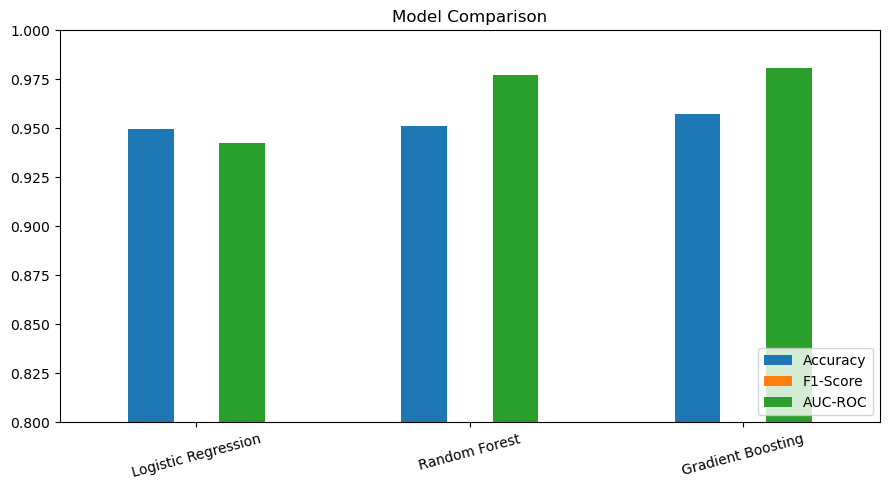

Chart saved to reports/


In [16]:
import matplotlib.pyplot as plt

# Bar chart comparison
results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC':  roc_auc_score(y_test, y_prob)
    }

import pandas as pd
results_df = pd.DataFrame(results).T
results_df.plot(kind='bar', figsize=(9,5), ylim=(0.8, 1.0))
plt.title('Model Comparison')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('reports/notebook_model_comparison.png', dpi=150)
plt.show()
print("Chart saved to reports/")